In [2]:
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter

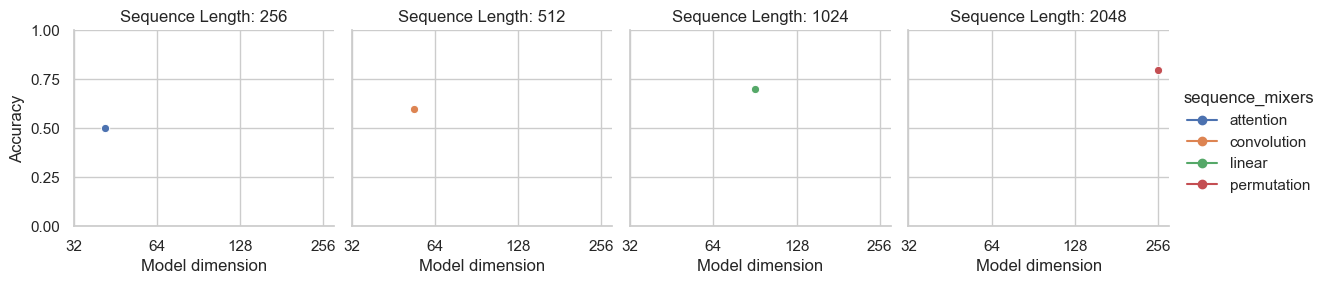

<Figure size 640x480 with 0 Axes>

In [42]:
seq_len = [256, 512, 1024, 2048]
d_model = [32, 64, 128, 256]

data = pd.DataFrame({
    "sequence_mixers": ["attention", "convolution", "linear", "permutation"],
    "seq_len": [256, 512, 1024, 2048],
    "d_model": [32, 64, 128, 256],
    "valid/accuracy": [0.5, 0.6, 0.7, 0.8]
})

sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=data,
    y="valid/accuracy",
    col=[256, 512, 1024, 2048],
    x="d_model",
    hue="sequence_mixers",
    kind="line",
    marker="o",
    height=3,
    aspect=1,
)
g.set(xscale="linear", ylabel="Accuracy", xlabel="Model dimension")

# Set custom x-ticks
ticks = np.linspace(0, 256, num=4)
# ticks = [32, 64, 128, 256] # Modify this list as needed
g.axes.flat[0].set_xticks(ticks)
for ax in g.axes.flat:
    ax.set_xticks(ticks)
    ax.set_xticklabels(['32', '64', '128', '256'])

    
# Set custom y-ticks
y_ticks = [0, 0.25, 0.5, 0.75, 1.0]
for ax in g.axes.flat:
    ax.set_yticks(y_ticks)

for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(f"Sequence Length: {title}")

plt.show()
plt.savefig("accuracy.png")


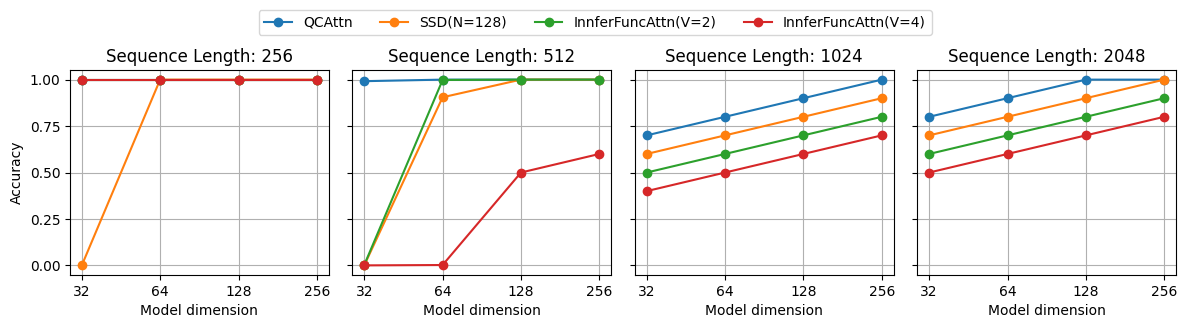

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, FixedLocator

sequence_mixers = ["QCAttn", "SSD(N=128)", "InnferFuncAttn(V=2)", "InnferFuncAttn(V=4)"]
seq_len = [256, 512, 1024, 2048]
d_model = [32, 64, 128, 256]

attention_valid_accuracy = {
    256: {32: 1.0, 64: 1.0, 128: 1.0, 256: 1.0},
    512: {32: 0.9916, 64: 1.0, 128: 1.0, 256: 1.0},
    1024: {32: 0.7, 64: 0.8, 128: 0.9, 256: 1.0},
    2048: {32: 0.8, 64: 0.9, 128: 1.0, 256: 1.0},
}

ssd_n128_valid_accuracy = {
    256: {32: 0.0000625, 64: 1.0, 128: 1.0, 256: 1.0},
    512: {32: 0.0001875, 64: 0.90506, 128: 1.0, 256: 1.0},
    1024: {32: 0.6, 64: 0.7, 128: 0.8, 256: 0.9},
    2048: {32: 0.7, 64: 0.8, 128: 0.9, 256: 1.0},
}

inner_func_v2_valid_accuracy = {
    256: {32: 1.0, 64: 1.0, 128: 1.0, 256: 1.0},
    512: {32: 0.00225, 64: 0.99809, 128: 1.0, 256: 1.0},
    1024: {32: 0.5, 64: 0.6, 128: 0.7, 256: 0.8},
    2048: {32: 0.6, 64: 0.7, 128: 0.8, 256: 0.9},
}

inner_func_v4_valid_accuracy = {
    256: {32: 1.0, 64: 1.0, 128: 1.0, 256: 1.0},
    512: {32: 0.0003125, 64: 0.00225, 128: 0.5, 256: 0.6},
    1024: {32: 0.4, 64: 0.5, 128: 0.6, 256: 0.7},
    2048: {32: 0.5, 64: 0.6, 128: 0.7, 256: 0.8},
}

mixer2valid_accuracy = {
    "QCAttn": attention_valid_accuracy,
    "SSD(N=128)": ssd_n128_valid_accuracy,
    "InnferFuncAttn(V=2)": inner_func_v2_valid_accuracy,
    "InnferFuncAttn(V=4)": inner_func_v4_valid_accuracy,
}

fig, axs = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
handles = []

for i, seq_len in enumerate([256, 512, 1024, 2048]):
    ax = axs[i]
    for mixer in sequence_mixers:
        valid_accuracy = [mixer2valid_accuracy[mixer][seq_len][d] for d in d_model]
        line, = ax.plot(d_model, valid_accuracy, marker='o', label=mixer)
        if i == 0:
            handles.append(line)
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.set_xticks([32, 64, 128, 256])
    # ax.set_xticklabels(['32', '64', '128', '256'])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title(f"Sequence Length: {seq_len}")
    ax.set_xlabel("Model dimension")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Accuracy")

fig.legend(handles=handles, loc='upper center', ncol=len(sequence_mixers), bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
plt.show()

In [8]:
import torch

x = torch.ones(1, 2, 4)
# print(x)
v_embed = torch.ones(1, 2, 1 ,2)
# print(v_embed)
print(torch.einsum('b t k d -> b t d', v_embed))
print(torch.einsum('b t d, b t k d -> b t k', x, v_embed))

tensor([[[1., 1.],
         [1., 1.]]])


RuntimeError: einsum(): subscript d has size 2 for operand 1 which does not broadcast with previously seen size 4